<a href="https://colab.research.google.com/github/fcoliveira-utfpr/aquacrop_ml/blob/main/04_treinamento_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Início - Bibliotecas**
---

In [10]:
# Para acessar os dados, basta executar este bloco de código
!pip install xgboost optuna    -q
!pip install lightgbm    -q
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score
from sklearn.neural_network import MLPRegressor
from sklearn.datasets import make_regression
from sklearn.linear_model import LinearRegression, Ridge
from sklearn import linear_model
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor

import joblib
import os

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 17.7 MB/s eta 0:00:00


In [11]:
url = "https://raw.githubusercontent.com/fcoliveira-utfpr/aquacrop_ml/refs/heads/main/df_wide.csv"
df_wide = pd.read_csv(url)
df_wide = df_wide[(df_wide['Ano'] >= 2007) & (df_wide['Ano'] <= 2020)]
df_wide.drop(columns=['Ano'], inplace=True)
#df_wide
corr = df_wide.corr(numeric_only=True)['Yield_obs'].drop('Yield_obs')
todas = corr.abs().sort_values(ascending=False)
todas.index

Index(['UR_F1', 'T_DEF_F1', 'DEF_F1', 'Tmax_F1', 'Tmed_F2', 'Tmed_F1',
       'Tmax_F2', 'UR_F2', 'ISNA_F1', 'Tmin_F2', 'Tmin_F3', 'T_DEF_F2',
       'ETc_F1', 'DEF_F2', 'Altitude_F1', 'Amp_F4', 'Tmin_F1', 'Pefetiva_F1',
       'PA_F2', 'Tmed_F3', 'Chuva_F1', 'Tmin_F4', 'ISNA_F2', 'PA_F3', 'EXC_F1',
       'Longitude_F1', 'PA_F4', 'Amp_F3', 'Chuva_F2', 'ARM_F1', 'ETR_F4',
       'EXC_F2', 'ETR_F2', 'Pefetiva_F2', 'ARM_F3', 'Tmed_F4', 'ARM_F2',
       'Tmax_F3', 'ETc_F2', 'ETR_F1', 'Amp_F1', 'Latitude_F1', 'ETR_F3',
       'UR_F4', 'T_DEF_F4', 'DEF_F4', 'ISNA_F3', 'Pefetiva_F4', 'ISNA_F4',
       'UR_F3', 'Tmax_F4', 'lat_lon_F1', 'EXC_F3', 'ETc_F3', 'ETc_F4', 'PA_F1',
       'Chuva_F3', 'ARM_F4', 'DEF_F3', 'Chuva_F4', 'Amp_F2', 'EXC_F4',
       'Pefetiva_F3', 'T_DEF_F3', 'DOY_semeadura', 'DOY_maturacao'],
      dtype='object')

#RandomForest

[I 2026-03-17 11:44:08,359] A new study created in memory with name: no-name-d4159b5e-8047-4301-9009-4318d77fbab3



🔎 Iniciando otimização com Optuna...



  0%|          | 0/40 [00:00<?, ?it/s]

[I 2026-03-17 11:44:46,337] Trial 0 finished with value: 503.1110478946006 and parameters: {'n_estimators': 455, 'max_depth': 32, 'min_samples_split': 9, 'min_samples_leaf': 2, 'max_features': None, 'bootstrap': True}. Best is trial 0 with value: 503.1110478946006.
[I 2026-03-17 11:45:24,091] Trial 1 finished with value: 506.84320968630175 and parameters: {'n_estimators': 479, 'max_depth': 39, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': None, 'bootstrap': True}. Best is trial 0 with value: 503.1110478946006.
[I 2026-03-17 11:45:36,754] Trial 2 finished with value: 516.7393027365603 and parameters: {'n_estimators': 228, 'max_depth': 28, 'min_samples_split': 11, 'min_samples_leaf': 7, 'max_features': None, 'bootstrap': True}. Best is trial 0 with value: 503.1110478946006.
[I 2026-03-17 11:45:52,107] Trial 3 finished with value: 535.3336995730871 and parameters: {'n_estimators': 347, 'max_depth': 6, 'min_samples_split': 4, 'min_samples_leaf': 7, 'max_features': None, '

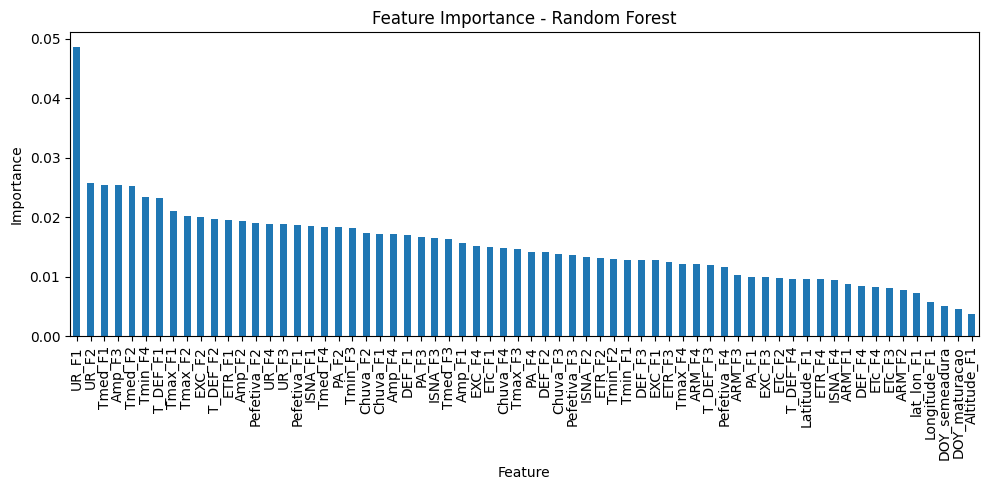

In [ ]:
# ==========================================================
# RANDOM FOREST + OPTUNA
# ==========================================================

import numpy as np
import pandas as pd
import optuna

from sklearn.model_selection import train_test_split, cross_val_score, TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ==========================================================
# ORGANIZAR DATAFRAME
# ==========================================================

# FEATURES
X = df_wide[todas.index]

# TARGET
y = df_wide['Yield_obs']

# ==========================================================
# TRAIN / TEST SPLIT TEMPORAL
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False
)

# ==========================================================
# VALIDAÇÃO CRUZADA
# ==========================================================

from sklearn.model_selection import TimeSeriesSplit

cv = TimeSeriesSplit(n_splits=5)

# ==========================================================
# FUNÇÃO OBJETIVO DO OPTUNA
# ==========================================================

def objective(trial):

    params = {

        "n_estimators": trial.suggest_int("n_estimators", 200, 600),

        "max_depth": trial.suggest_int("max_depth", 3, 40),

        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),

        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),

        "max_features": trial.suggest_categorical(
            "max_features",
            ["sqrt", "log2", None]
        ),

        "bootstrap": trial.suggest_categorical(
            "bootstrap",
            [True, False]
        )
    }

    model = RandomForestRegressor(
        **params,
        random_state=42,
        n_jobs=-1
    )

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="neg_mean_absolute_error",
        n_jobs=-1
    )

    # converter erro negativo para positivo
    return -scores.mean()

# ==========================================================
# CRIAR ESTUDO OPTUNA
# ==========================================================

study = optuna.create_study(direction="minimize")

print("\n🔎 Iniciando otimização com Optuna...\n")

study.optimize(
    objective,
    n_trials=40,
    show_progress_bar=True
)

# ==========================================================
# MELHORES HIPERPARÂMETROS
# ==========================================================

print("\n🏆 Melhores hiperparâmetros encontrados:")
print(study.best_params)

# ==========================================================
# TREINAR MODELO FINAL
# ==========================================================

best_model = RandomForestRegressor(
    **study.best_params,
    random_state=42,
    n_jobs=-1
)

best_model.fit(X_train, y_train)

# ==========================================================
# PREVISÃO
# ==========================================================

y_pred = best_model.predict(X_test)

# ==========================================================
# MÉTRICAS
# ==========================================================

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

mape = np.mean(np.abs((y_test - y_pred) / (y_test + 1e-6))) * 100

print("\n" + "="*60)
print("RESULTADOS NO CONJUNTO DE TESTE")
print("="*60)

print(f"R²   : {r2:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAPE : {mape:.2f}%")

# ==========================================================
# IMPORTÂNCIA DAS VARIÁVEIS
# ==========================================================

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n" + "="*60)
print("IMPORTÂNCIA DAS FEATURES")
print("="*60)

print(importance)

# ==========================================================
# GRÁFICO DE IMPORTÂNCIA
# ==========================================================

import matplotlib.pyplot as plt

importance.plot(
    x='Feature',
    y='Importance',
    kind='bar',
    figsize=(10,5),
    legend=False
)

plt.title('Feature Importance - Random Forest')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

[I 2026-03-17 10:32:18,001] A new study created in memory with name: no-name-95e959f4-a5d5-4581-b156-eb1e352694bc



🔎 Iniciando otimização com Optuna...



  0%|          | 0/40 [00:00<?, ?it/s]

[I 2026-03-17 10:32:21,168] Trial 0 finished with value: 516.8814261353006 and parameters: {'n_estimators': 247, 'max_depth': 32, 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': 'log2', 'bootstrap': True}. Best is trial 0 with value: 516.8814261353006.
[I 2026-03-17 10:32:26,968] Trial 1 finished with value: 522.9116842746475 and parameters: {'n_estimators': 361, 'max_depth': 40, 'min_samples_split': 18, 'min_samples_leaf': 9, 'max_features': 'log2', 'bootstrap': False}. Best is trial 0 with value: 516.8814261353006.
[I 2026-03-17 10:32:32,386] Trial 2 finished with value: 528.3369756436643 and parameters: {'n_estimators': 390, 'max_depth': 16, 'min_samples_split': 18, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 0 with value: 516.8814261353006.
[I 2026-03-17 10:32:39,368] Trial 3 finished with value: 501.3051717497433 and parameters: {'n_estimators': 372, 'max_depth': 40, 'min_samples_split': 10, 'min_samples_leaf': 6, 'max_features'

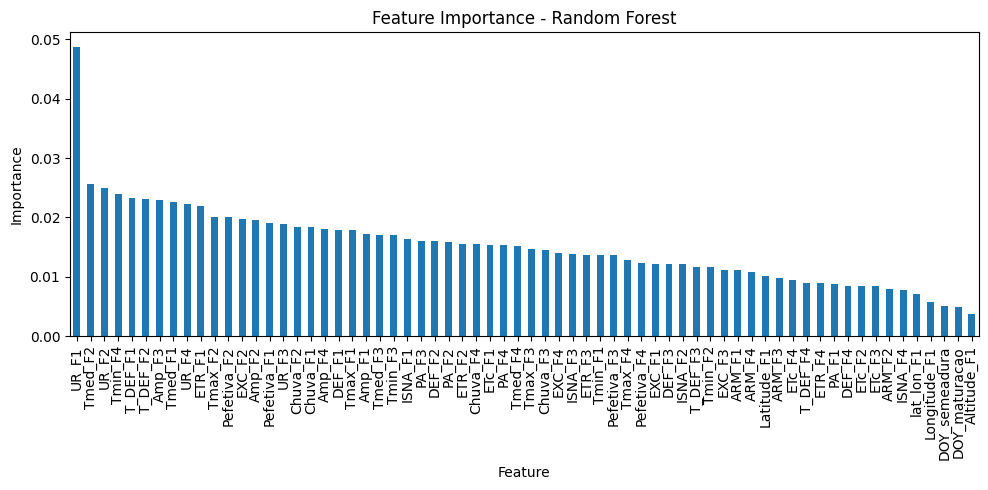

In [ ]:
# ==========================================================
# RANDOM FOREST + OPTUNA
# ==========================================================

import numpy as np
import pandas as pd
import optuna

from sklearn.model_selection import train_test_split, cross_val_score, TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ==========================================================
# ORGANIZAR DATAFRAME
# ==========================================================

# FEATURES
X = df_wide[todas.index]

# TARGET
y = df_wide['Yield_obs']

# ==========================================================
# TRAIN / TEST SPLIT TEMPORAL
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False
)

# ==========================================================
# VALIDAÇÃO CRUZADA
# ==========================================================

from sklearn.model_selection import TimeSeriesSplit

cv = TimeSeriesSplit(n_splits=5)

# ==========================================================
# FUNÇÃO OBJETIVO DO OPTUNA
# ==========================================================

def objective(trial):

    params = {

        "n_estimators": trial.suggest_int("n_estimators", 200, 600),

        "max_depth": trial.suggest_int("max_depth", 3, 40),

        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),

        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),

        "max_features": trial.suggest_categorical(
            "max_features",
            ["sqrt", "log2", None]
        ),

        "bootstrap": trial.suggest_categorical(
            "bootstrap",
            [True, False]
        )
    }

    model = RandomForestRegressor(
        **params,
        random_state=42,
        n_jobs=-1
    )

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="neg_mean_absolute_error",
        n_jobs=-1
    )

    # converter erro negativo para positivo
    return -scores.mean()

# ==========================================================
# CRIAR ESTUDO OPTUNA
# ==========================================================

study = optuna.create_study(direction="minimize")

print("\n🔎 Iniciando otimização com Optuna...\n")

study.optimize(
    objective,
    n_trials=40,
    show_progress_bar=True
)

# ==========================================================
# MELHORES HIPERPARÂMETROS
# ==========================================================

print("\n🏆 Melhores hiperparâmetros encontrados:")
print(study.best_params)

# ==========================================================
# TREINAR MODELO FINAL
# ==========================================================

best_model = RandomForestRegressor(
    **study.best_params,
    random_state=42,
    n_jobs=-1
)

best_model.fit(X_train, y_train)

# ==========================================================
# PREVISÃO
# ==========================================================

y_pred = best_model.predict(X_test)

# ==========================================================
# MÉTRICAS
# ==========================================================

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

mape = np.mean(np.abs((y_test - y_pred) / (y_test + 1e-6))) * 100

print("\n" + "="*60)
print("RESULTADOS NO CONJUNTO DE TESTE")
print("="*60)

print(f"R²   : {r2:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAPE : {mape:.2f}%")

# ==========================================================
# IMPORTÂNCIA DAS VARIÁVEIS
# ==========================================================

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n" + "="*60)
print("IMPORTÂNCIA DAS FEATURES")
print("="*60)

print(importance)

# ==========================================================
# GRÁFICO DE IMPORTÂNCIA
# ==========================================================

import matplotlib.pyplot as plt

importance.plot(
    x='Feature',
    y='Importance',
    kind='bar',
    figsize=(10,5),
    legend=False
)

plt.title('Feature Importance - Random Forest')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

In [ ]:
features_i = importance[importance['Importance'] >= 0.015]
features_i = features_i['Feature'].to_list()
features_i

['UR_F1',
 'Tmed_F2',
 'UR_F2',
 'Tmin_F4',
 'T_DEF_F1',
 'T_DEF_F2',
 'Amp_F3',
 'Tmed_F1',
 'UR_F4',
 'ETR_F1',
 'Tmax_F2',
 'Pefetiva_F2',
 'EXC_F2',
 'Amp_F2',
 'Pefetiva_F1',
 'UR_F3',
 'Chuva_F2',
 'Chuva_F1',
 'Amp_F4',
 'DEF_F1',
 'Tmax_F1',
 'Amp_F1',
 'Tmed_F3',
 'Tmin_F3',
 'ISNA_F1',
 'PA_F3',
 'DEF_F2',
 'PA_F2',
 'ETR_F2',
 'Chuva_F4',
 'ETc_F1',
 'PA_F4',
 'Tmed_F4']

#XGBRegressor

[I 2026-03-17 12:44:56,305] A new study created in memory with name: no-name-68730ffd-9c3c-4098-9279-fd582f97a9d6



🔎 Iniciando otimização com Optuna...



  0%|          | 0/40 [00:00<?, ?it/s]

[I 2026-03-17 12:45:41,121] Trial 0 finished with value: 485.93552482961286 and parameters: {'n_estimators': 173, 'max_depth': 12, 'learning_rate': 0.014598926771651205, 'subsample': 0.8475930078345336, 'colsample_bytree': 0.933268512659799, 'gamma': 2.0793320065912684, 'reg_alpha': 0.013625741530844193, 'reg_lambda': 2.440310252195202e-06}. Best is trial 0 with value: 485.93552482961286.
[I 2026-03-17 12:46:35,385] Trial 1 finished with value: 470.1675959831775 and parameters: {'n_estimators': 566, 'max_depth': 8, 'learning_rate': 0.0163499326771, 'subsample': 0.9413226476902332, 'colsample_bytree': 0.7685153422058966, 'gamma': 3.168556364711371, 'reg_alpha': 0.9026745184153528, 'reg_lambda': 0.021409920360873875}. Best is trial 1 with value: 470.1675959831775.
[I 2026-03-17 12:46:40,931] Trial 2 finished with value: 480.521749642134 and parameters: {'n_estimators': 421, 'max_depth': 8, 'learning_rate': 0.23374374687979904, 'subsample': 0.980788336179288, 'colsample_bytree': 0.5947337

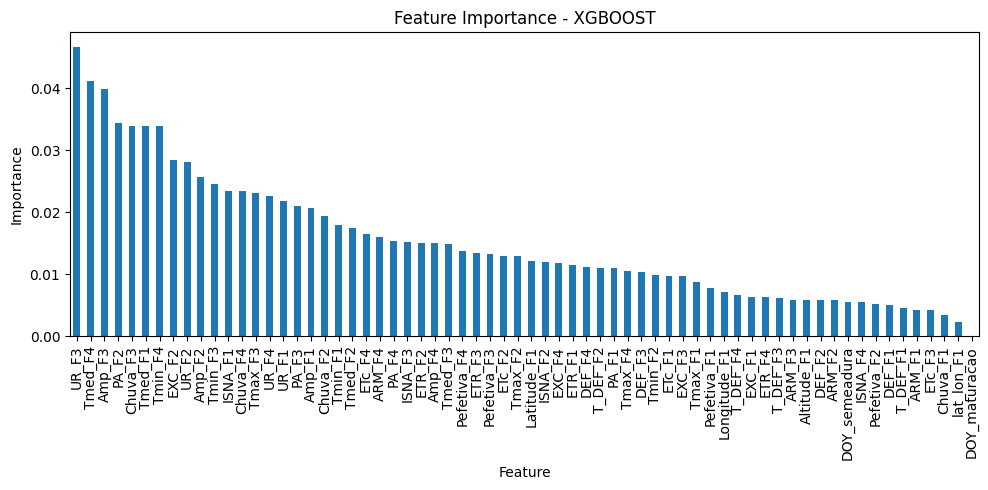

In [ ]:
# ==========================================================
# OTIMIZAÇÃO DE XGBOOST COM OPTUNA
# Partindo de X (DataFrame) e y (Series)
# ==========================================================

import numpy as np
import pandas as pd
import optuna

from sklearn.model_selection import train_test_split, cross_val_score, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor


# ==========================================================
# ORGANIZAR DATAFRAME
# ==========================================================

# FEATURES
X = df_wide[todas.index]

# TARGET
y = df_wide['Yield_obs']

# ==========================================================
# TRAIN / TEST SPLIT TEMPORAL
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False
)

# ==========================================================
# VALIDAÇÃO CRUZADA
# ==========================================================

from sklearn.model_selection import TimeSeriesSplit

cv = TimeSeriesSplit(n_splits=5)

# ==========================================================
# FUNÇÃO OBJETIVO DO OPTUNA
# ==========================================================

def objective(trial):

    params = {

        "n_estimators": trial.suggest_int("n_estimators", 100, 800),

        "max_depth": trial.suggest_int("max_depth", 3, 12),

        "learning_rate": trial.suggest_float(
            "learning_rate",
            0.01,
            0.3,
            log=True
        ),

        "subsample": trial.suggest_float(
            "subsample",
            0.5,
            1.0
        ),

        "colsample_bytree": trial.suggest_float(
            "colsample_bytree",
            0.5,
            1.0
        ),

        "gamma": trial.suggest_float(
            "gamma",
            0,
            5
        ),

        "reg_alpha": trial.suggest_float(
            "reg_alpha",
            1e-8,
            10,
            log=True
        ),

        "reg_lambda": trial.suggest_float(
            "reg_lambda",
            1e-8,
            10,
            log=True
        )
    }

    model = XGBRegressor(
        **params,
        random_state=42,
        n_jobs=-1,
        tree_method="hist"
    )

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="neg_mean_absolute_error",
        n_jobs=-1
    )

    return -scores.mean()

# ==========================================================
# CRIAR ESTUDO OPTUNA
# ==========================================================

study = optuna.create_study(direction="minimize")

print("\n🔎 Iniciando otimização com Optuna...\n")

study.optimize(
    objective,
    n_trials=40,
    show_progress_bar=True
)

# ==========================================================
# MELHORES HIPERPARÂMETROS
# ==========================================================

print("\n🏆 Melhores hiperparâmetros encontrados:")
print(study.best_params)

# ==========================================================
# TREINAR MODELO FINAL
# ==========================================================

best_model = XGBRegressor(
    **study.best_params,
    random_state=42,
    n_jobs=-1,
    tree_method="hist"
)

best_model.fit(X_train, y_train)

# ==========================================================
# PREVISÃO
# ==========================================================

y_pred = best_model.predict(X_test)

# ==========================================================
# MÉTRICAS
# ==========================================================

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

mape = np.mean(np.abs((y_test - y_pred) / (y_test + 1e-6))) * 100

print("\n" + "="*60)
print("RESULTADOS NO CONJUNTO DE TESTE")
print("="*60)

print(f"R²   : {r2:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAPE : {mape:.2f}%")

# ==========================================================
# IMPORTÂNCIA DAS VARIÁVEIS
# ==========================================================

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n" + "="*60)
print("IMPORTÂNCIA DAS FEATURES")
print("="*60)

print(importance)

# ==========================================================
# GRÁFICO DE IMPORTÂNCIA
# ==========================================================

import matplotlib.pyplot as plt

importance.plot(
    x='Feature',
    y='Importance',
    kind='bar',
    figsize=(10,5),
    legend=False
)

plt.title('Feature Importance - XGBOOST')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

#ExtraTrees

[I 2026-03-17 13:15:51,015] A new study created in memory with name: no-name-a5248112-e8b5-4c94-aa2f-a054509c3117



🔎 Iniciando otimização com Optuna...



  0%|          | 0/40 [00:00<?, ?it/s]

[I 2026-03-17 13:16:04,045] Trial 0 finished with value: 529.65888018837 and parameters: {'n_estimators': 751, 'max_depth': 15, 'min_samples_split': 20, 'min_samples_leaf': 6, 'max_features': None, 'bootstrap': False}. Best is trial 0 with value: 529.65888018837.
[I 2026-03-17 13:16:08,175] Trial 1 finished with value: 609.8999926133182 and parameters: {'n_estimators': 744, 'max_depth': 4, 'min_samples_split': 17, 'min_samples_leaf': 1, 'max_features': 'log2', 'bootstrap': False}. Best is trial 0 with value: 529.65888018837.
[I 2026-03-17 13:16:12,450] Trial 2 finished with value: 579.6338080403154 and parameters: {'n_estimators': 630, 'max_depth': 16, 'min_samples_split': 15, 'min_samples_leaf': 9, 'max_features': 'sqrt', 'bootstrap': False}. Best is trial 0 with value: 529.65888018837.
[I 2026-03-17 13:16:16,908] Trial 3 finished with value: 551.630968484019 and parameters: {'n_estimators': 407, 'max_depth': 15, 'min_samples_split': 12, 'min_samples_leaf': 2, 'max_features': 'sqrt', 

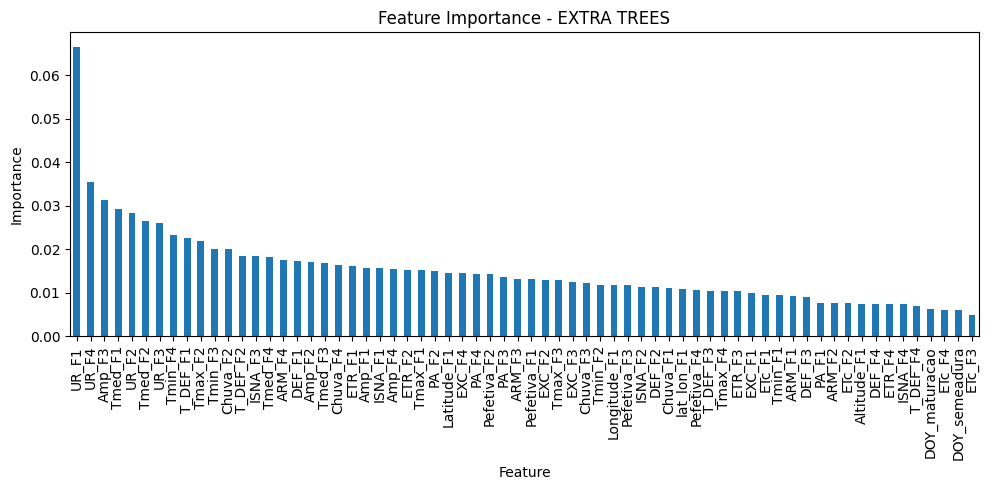

In [ ]:
# ==========================================================
# OTIMIZAÇÃO DE EXTRA TREES COM OPTUNA
# Partindo de X (DataFrame) e y (Series)
# ==========================================================

import numpy as np
import pandas as pd
import optuna

from sklearn.model_selection import train_test_split, cross_val_score, TimeSeriesSplit
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ==========================================================
# ORGANIZAR DATAFRAME
# ==========================================================

# FEATURES
X = df_wide[todas.index]

# TARGET
y = df_wide['Yield_obs']

# ==========================================================
# TRAIN / TEST SPLIT TEMPORAL
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False
)

# ==========================================================
# VALIDAÇÃO CRUZADA
# ==========================================================

from sklearn.model_selection import TimeSeriesSplit

cv = TimeSeriesSplit(n_splits=5)

# ==========================================================
# FUNÇÃO OBJETIVO
# ==========================================================

def objective(trial):

    params = {

        "n_estimators": trial.suggest_int("n_estimators", 100, 800),

        "max_depth": trial.suggest_int("max_depth", 3, 30),

        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),

        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),

        "max_features": trial.suggest_categorical(
            "max_features",
            ["sqrt", "log2", None]
        ),

        "bootstrap": trial.suggest_categorical(
            "bootstrap",
            [True, False]
        )
    }

    model = ExtraTreesRegressor(
        **params,
        random_state=42,
        n_jobs=-1
    )

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="neg_mean_absolute_error",
        n_jobs=-1
    )
    return -scores.mean()

# ==========================================================
# CRIAR ESTUDO OPTUNA
# ==========================================================

study = optuna.create_study(direction="minimize")

print("\n🔎 Iniciando otimização com Optuna...\n")

study.optimize(
    objective,
    n_trials=40,
    show_progress_bar=True
)

# ==========================================================
# MELHORES HIPERPARÂMETROS
# ==========================================================

print("\n🏆 Melhores hiperparâmetros encontrados:")
print(study.best_params)

# ==========================================================
# TREINAR MODELO FINAL
# ==========================================================

best_model = ExtraTreesRegressor(
    **study.best_params,
    random_state=42,
    n_jobs=-1
)

best_model.fit(X_train, y_train)

# ==========================================================
# PREVISÃO
# ==========================================================

y_pred = best_model.predict(X_test)

# ==========================================================
# MÉTRICAS
# ==========================================================

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

mape = np.mean(np.abs((y_test - y_pred) / (y_test + 1e-6))) * 100

print("\n" + "="*60)
print("RESULTADOS NO CONJUNTO DE TESTE")
print("="*60)

print(f"R²   : {r2:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAPE : {mape:.2f}%")

# ==========================================================
# IMPORTÂNCIA DAS VARIÁVEIS
# ==========================================================

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n" + "="*60)
print("IMPORTÂNCIA DAS FEATURES")
print("="*60)

print(importance)

# ==========================================================
# GRÁFICO DE IMPORTÂNCIA
# ==========================================================

import matplotlib.pyplot as plt

importance.plot(
    x='Feature',
    y='Importance',
    kind='bar',
    figsize=(10,5),
    legend=False
)

plt.title('Feature Importance - EXTRA TREES')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

#LGBMRegressor

[I 2026-03-17 14:38:48,679] A new study created in memory with name: no-name-ad382a4d-5690-4d67-8273-b95d94571753



🔎 Iniciando otimização com Optuna...



  0%|          | 0/40 [00:00<?, ?it/s]

[I 2026-03-17 14:39:43,968] Trial 0 finished with value: 449.55750362813114 and parameters: {'n_estimators': 493, 'learning_rate': 0.0842915360657413, 'max_depth': 4, 'num_leaves': 164, 'min_child_samples': 18, 'subsample': 0.8136146670968838, 'colsample_bytree': 0.9065668196909538, 'reg_alpha': 2.570669206212578, 'reg_lambda': 3.900273555877196}. Best is trial 0 with value: 449.55750362813114.
[I 2026-03-17 14:39:56,128] Trial 1 finished with value: 466.420727353959 and parameters: {'n_estimators': 623, 'learning_rate': 0.07074524299076812, 'max_depth': 10, 'num_leaves': 67, 'min_child_samples': 32, 'subsample': 0.9313173562218546, 'colsample_bytree': 0.8591058341466715, 'reg_alpha': 8.586529743074625, 'reg_lambda': 6.465916234011359}. Best is trial 0 with value: 449.55750362813114.
[I 2026-03-17 14:40:05,909] Trial 2 finished with value: 555.3862930901557 and parameters: {'n_estimators': 909, 'learning_rate': 0.005136263587931142, 'max_depth': 3, 'num_leaves': 72, 'min_child_samples'

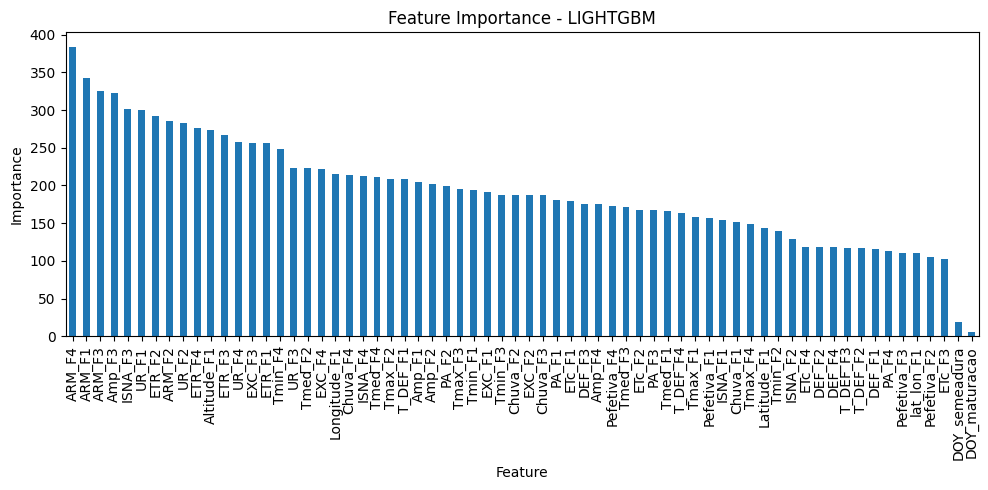

In [ ]:
# ==========================================================
# OTIMIZAÇÃO DE LIGHTGBM COM OPTUNA
# ==========================================================

import numpy as np
import pandas as pd
import optuna

from sklearn.model_selection import train_test_split, cross_val_score, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from lightgbm import LGBMRegressor

# ==========================================================
# ORGANIZAR DATAFRAME
# ==========================================================

# FEATURES
X = df_wide[todas.index]

# TARGET
y = df_wide['Yield_obs']

# ==========================================================
# TRAIN / TEST SPLIT TEMPORAL
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False
)

# ==========================================================
# VALIDAÇÃO CRUZADA
# ==========================================================

cv = TimeSeriesSplit(n_splits=5)

# ==========================================================
# FUNÇÃO OBJETIVO
# ==========================================================

def objective(trial):

    params = {

        "n_estimators": trial.suggest_int("n_estimators", 200, 1200),

        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.1),

        "max_depth": trial.suggest_int("max_depth", 3, 15),

        "num_leaves": trial.suggest_int("num_leaves", 10, 200),

        "min_child_samples": trial.suggest_int("min_child_samples", 5, 50),

        "subsample": trial.suggest_float("subsample", 0.6, 1.0),

        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),

        "reg_alpha": trial.suggest_float("reg_alpha", 0, 10),

        "reg_lambda": trial.suggest_float("reg_lambda", 0, 10)
    }

    model = LGBMRegressor(
        **params,
        random_state=42,
        n_jobs=-1
    )

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="neg_mean_absolute_error",
        n_jobs=-1
    )

    return -scores.mean()

# ==========================================================
# CRIAR ESTUDO OPTUNA
# ==========================================================

study = optuna.create_study(direction="minimize")

print("\n🔎 Iniciando otimização com Optuna...\n")

study.optimize(
    objective,
    n_trials=40,
    show_progress_bar=True
)

# ==========================================================
# MELHORES HIPERPARÂMETROS
# ==========================================================

print("\n🏆 Melhores hiperparâmetros encontrados:")
print(study.best_params)

# ==========================================================
# TREINAR MODELO FINAL
# ==========================================================

best_model = LGBMRegressor(
    **study.best_params,
    random_state=42,
    n_jobs=-1
)

best_model.fit(X_train, y_train)

# ==========================================================
# PREVISÃO
# ==========================================================

y_pred = best_model.predict(X_test)

# ==========================================================
# MÉTRICAS
# ==========================================================

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

mape = np.mean(np.abs((y_test - y_pred) / (y_test + 1e-6))) * 100

print("\n" + "="*60)
print("RESULTADOS NO CONJUNTO DE TESTE")
print("="*60)

print(f"R²   : {r2:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAPE : {mape:.2f}%")

# ==========================================================
# IMPORTÂNCIA DAS VARIÁVEIS
# ==========================================================

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n" + "="*60)
print("IMPORTÂNCIA DAS FEATURES")
print("="*60)

print(importance)

# ==========================================================
# GRÁFICO DE IMPORTÂNCIA
# ==========================================================

import matplotlib.pyplot as plt

importance.plot(
    x='Feature',
    y='Importance',
    kind='bar',
    figsize=(10,5),
    legend=False
)

plt.title('Feature Importance - LIGHTGBM')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

In [ ]:
study.best_params

{'n_estimators': 387,
 'learning_rate': 0.03490831083466142,
 'max_depth': 7,
 'num_leaves': 103,
 'min_child_samples': 5,
 'subsample': 0.9640624276684349,
 'colsample_bytree': 0.6883249224135735,
 'reg_alpha': 7.338105084413314,
 'reg_lambda': 3.663472652800299}

#Todos os modelos

In [12]:
# ==========================================================
# COMPARAÇÃO DE MODELOS ML
# RF, EXTRA TREES, XGBOOST, LIGHTGBM
# ==========================================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# ==========================================================
# DEFINIR X e y
# ==========================================================

X = df_wide[todas.index]
y = df_wide['Yield_obs']

# ==========================================================
# DIVISÃO TREINO / TESTE
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# ==========================================================
# DEFINIR MODELOS (MESMAS CONFIGURAÇÕES)
# ==========================================================

modelos = {

    'RandomForest': RandomForestRegressor(
        n_estimators=309,
        max_depth=19,
        min_samples_split=3,
        min_samples_leaf=1,
        max_features='log2',
        bootstrap=False,
        random_state=42,
        n_jobs=-1
    ),

    'ExtraTrees': ExtraTreesRegressor(
        n_estimators=680,
        max_depth=23,
        min_samples_split=2,
        min_samples_leaf=1,
        max_features=None,
        bootstrap=False,
        random_state=42,
        n_jobs=-1
    ),

    'XGBoost': XGBRegressor(
        n_estimators=763,
        max_depth=7,
        learning_rate=0.06002540718852424,
        subsample=0.7317094474013432,
        colsample_bytree=0.8048515232044022,
        gamma=3.420646935272431,
        reg_alpha=1.985885704116221e-07,
        reg_lambda=1.3899406131366012,
        random_state=42,
        n_jobs=-1
    ),

    'LightGBM': LGBMRegressor(
        n_estimators=387,
        learning_rate=0.03490831083466142,
        max_depth=7,
        num_leaves=103,
        min_child_samples=5,
        subsample=0.9640624276684349,
        colsample_bytree=0.6883249224135735,
        reg_alpha=7.338105084413314,
        reg_lambda=3.663472652800299,
        random_state=42,
        n_jobs=-1
    )}

# ==========================================================
# DATAFRAMES PARA RESULTADOS
# ==========================================================

resultados = []
importancias = []

# ==========================================================
# LOOP DE TREINAMENTO
# ==========================================================

for nome, modelo in modelos.items():

    print(f'Treinando {nome}...')

    modelo.fit(X_train, y_train)

    # previsão
    y_pred = modelo.predict(X_test)

    # métricas
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    resultados.append({
        'Modelo': nome,
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2
    })

    # importância
    if hasattr(modelo, 'feature_importances_'):

        imp = pd.DataFrame({
            'Feature': X.columns,
            'Importancia': modelo.feature_importances_
        })

        imp['Modelo'] = nome

        importancias.append(imp)

# ==========================================================
# DATAFRAMES FINAIS
# ==========================================================

df_resultados = pd.DataFrame(resultados)

df_importancia = pd.concat(importancias)

# ordenar importância
df_importancia = df_importancia.sort_values(
    ['Modelo','Importancia'],
    ascending=[True, False]
)

# ==========================================================
# RESULTADOS
# ==========================================================

print("\nRESULTADOS DOS MODELOS\n")
display(df_resultados)

print("\nIMPORTÂNCIA DAS VARIÁVEIS\n")
display(df_importancia)

Treinando RandomForest...
Treinando ExtraTrees...
Treinando XGBoost...
Treinando LightGBM...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006599 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 13460
[LightGBM] [Info] Number of data points in the train set: 672, number of used features: 66
[LightGBM] [Info] Start training from score 3154.208766
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits

,Modelo,MAE,RMSE,R2
0,RandomForest,288.773456,411.652048,0.712197
1,ExtraTrees,255.269147,368.382209,0.769521
2,XGBoost,277.167909,399.524449,0.728905
3,LightGBM,274.526260,404.222279,0.722493



IMPORTÂNCIA DAS VARIÁVEIS



,Feature,Importancia,Modelo
0,UR_F1,0.066826,ExtraTrees
43,UR_F4,0.036079,ExtraTrees
27,Amp_F3,0.031741,ExtraTrees
49,UR_F3,0.030336,ExtraTrees
7,UR_F2,0.029660,ExtraTrees
...,...,...,...
16,Tmin_F1,0.003223,XGBoost
9,Tmin_F2,0.003083,XGBoost
14,Altitude_F1,0.002907,XGBoost
53,ETc_F3,0.002374,XGBoost


In [13]:
df_resultados

,Modelo,MAE,RMSE,R2
0,RandomForest,288.773456,411.652048,0.712197
1,ExtraTrees,255.269147,368.382209,0.769521
2,XGBoost,277.167909,399.524449,0.728905
3,LightGBM,274.526260,404.222279,0.722493


In [ ]:
os.makedirs('modelos_salvos', exist_ok=True)

In [ ]:
modelos_treinados = {}

for nome, modelo in modelos.items():

    print(f'Treinando {nome}...')

    modelo.fit(X_train, y_train)

    # salvar modelo treinado no dicionário
    modelos_treinados[nome] = modelo

    # previsão
    y_pred = modelo.predict(X_test)

    # métricas
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    resultados.append({
        'Modelo': nome,
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2
    })

    # importância
    if hasattr(modelo, 'feature_importances_'):

        imp = pd.DataFrame({
            'Feature': X.columns,
            'Importancia': modelo.feature_importances_
        })

        imp['Modelo'] = nome
        importancias.append(imp)

# ==========================================================
# SALVAR MODELOS
# ==========================================================

for nome, modelo in modelos_treinados.items():
    caminho = f'modelos_salvos/{nome}.joblib'
    joblib.dump(modelo, caminho)
    print(f'Modelo {nome} salvo em: {caminho}')

Treinando RandomForest...
Treinando ExtraTrees...
Treinando XGBoost...
Treinando LightGBM...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000975 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 13460
[LightGBM] [Info] Number of data points in the train set: 672, number of used features: 66
[LightGBM] [Info] Start training from score 3154.208766
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits

#Imagens

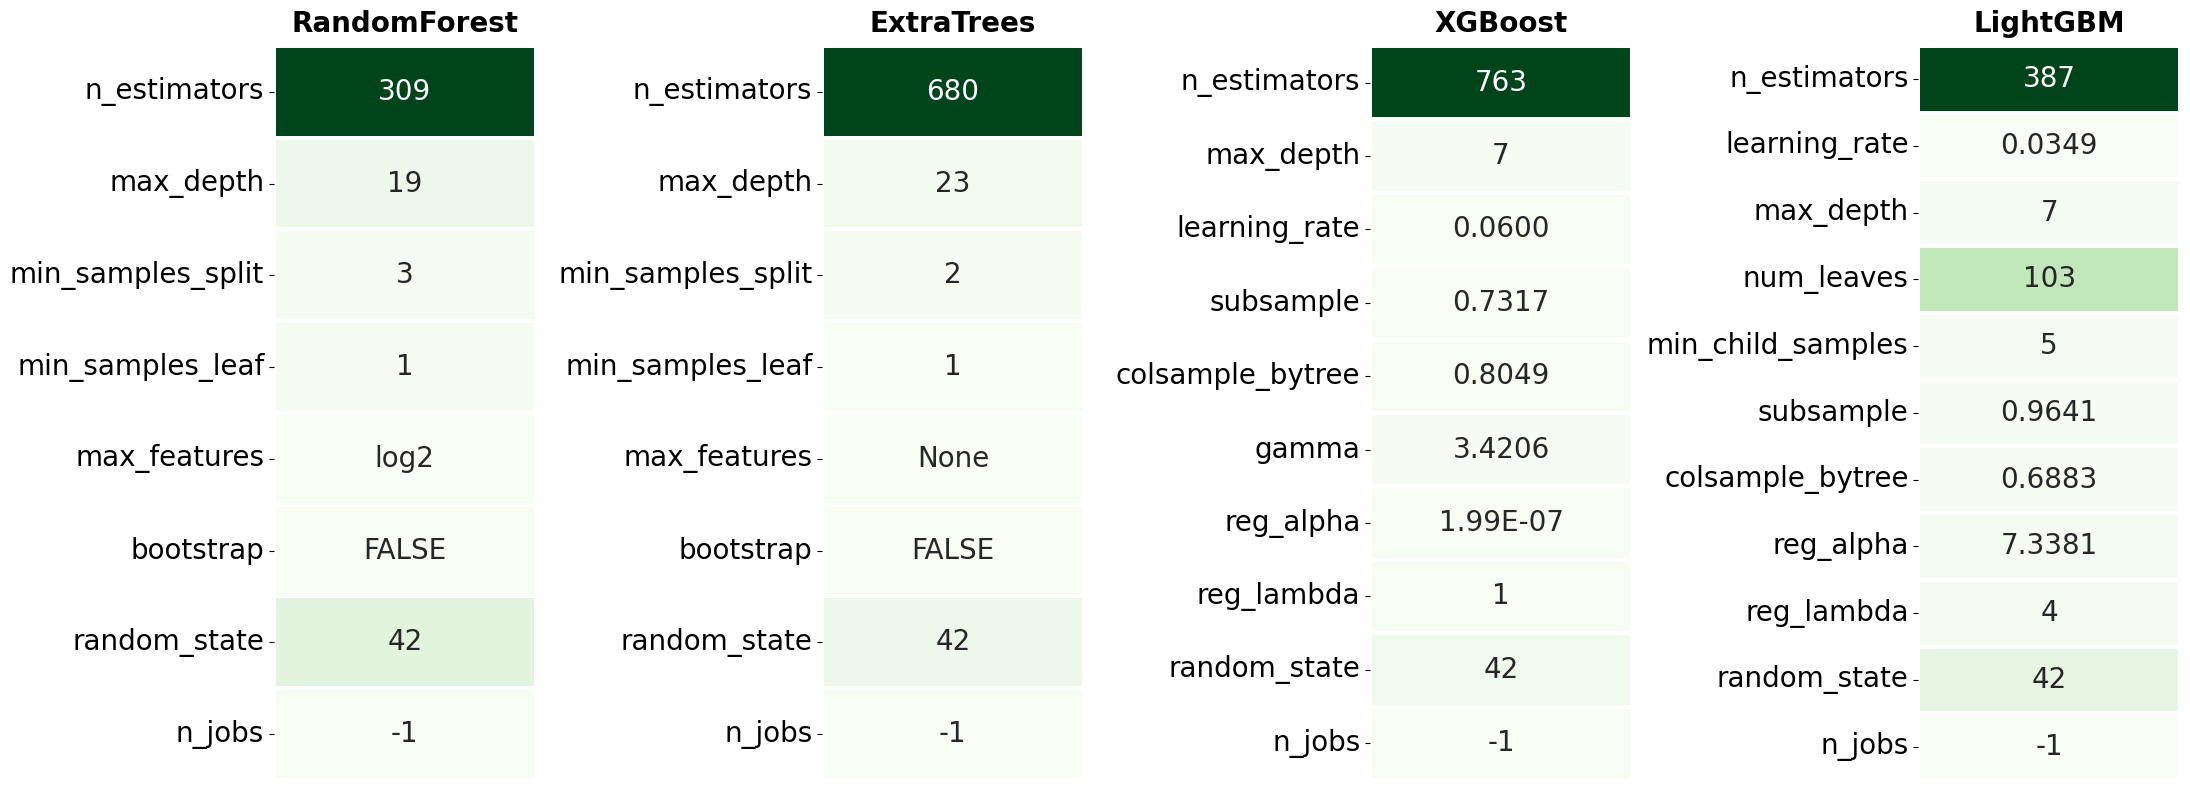

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import io

# 1. Dados completos
raw_data = """Modelo,Parâmetro,Valor calibrado
RandomForest,n_estimators,309
RandomForest,max_depth,19
RandomForest,min_samples_split,3
RandomForest,min_samples_leaf,1
RandomForest,max_features,log2
RandomForest,bootstrap,FALSE
RandomForest,random_state,42
RandomForest,n_jobs,-1
ExtraTrees,n_estimators,680
ExtraTrees,max_depth,23
ExtraTrees,min_samples_split,2
ExtraTrees,min_samples_leaf,1
ExtraTrees,max_features,None
ExtraTrees,bootstrap,FALSE
ExtraTrees,random_state,42
ExtraTrees,n_jobs,-1
XGBoost,n_estimators,763
XGBoost,max_depth,7
XGBoost,learning_rate,0.0600
XGBoost,subsample,0.7317
XGBoost,colsample_bytree,0.8049
XGBoost,gamma,3.4206
XGBoost,reg_alpha,1.99E-07
XGBoost,reg_lambda,1
XGBoost,random_state,42
XGBoost,n_jobs,-1
LightGBM,n_estimators,387
LightGBM,learning_rate,0.0349
LightGBM,max_depth,7
LightGBM,num_leaves,103
LightGBM,min_child_samples,5
LightGBM,subsample,0.9641
LightGBM,colsample_bytree,0.6883
LightGBM,reg_alpha,7.3381
LightGBM,reg_lambda,4
LightGBM,random_state,42
LightGBM,n_jobs,-1"""

df = pd.read_csv(io.StringIO(raw_data))
df['Valor calibrado'] = df['Valor calibrado'].fillna('None')

# 2. Preparação do Plot (1 linha, 4 colunas)
models = df['Modelo'].unique()
fig, axes = plt.subplots(1, 4, figsize=(22, 8), sharey=False)
fig.patch.set_facecolor('white')

for i, model in enumerate(models):
    # Filtra dados do modelo
    model_df = df[df['Modelo'] == model].copy()

    # Criamos uma coluna numérica fictícia para o "brilho" das cores do heatmap
    # Valores maiores ou textos diferentes ganharão intensidades diferentes
    model_df['color_val'] = pd.to_numeric(model_df['Valor calibrado'], errors='coerce').fillna(0)

    # Pivota os dados para o formato do heatmap
    plot_data = model_df.set_index('Parâmetro')[['color_val']]
    labels = model_df.set_index('Parâmetro')[['Valor calibrado']]

    # Desenha o heatmap
    sns.heatmap(plot_data,
                annot=labels,
                fmt="",
                cmap="Greens",
                cbar=False,
                linewidths=1.5,
                linecolor='white',
                annot_kws={"size": 20},
                ax=axes[i])

    # Estilização individual
    axes[i].set_title(model, fontsize=20, fontweight='bold', pad=10)
    axes[i].set_xlabel("")
    axes[i].set_xticks([])
    axes[i].set_ylabel("")
    axes[i].tick_params(axis='y', rotation=0, labelsize=20)


plt.tight_layout()
plt.show()

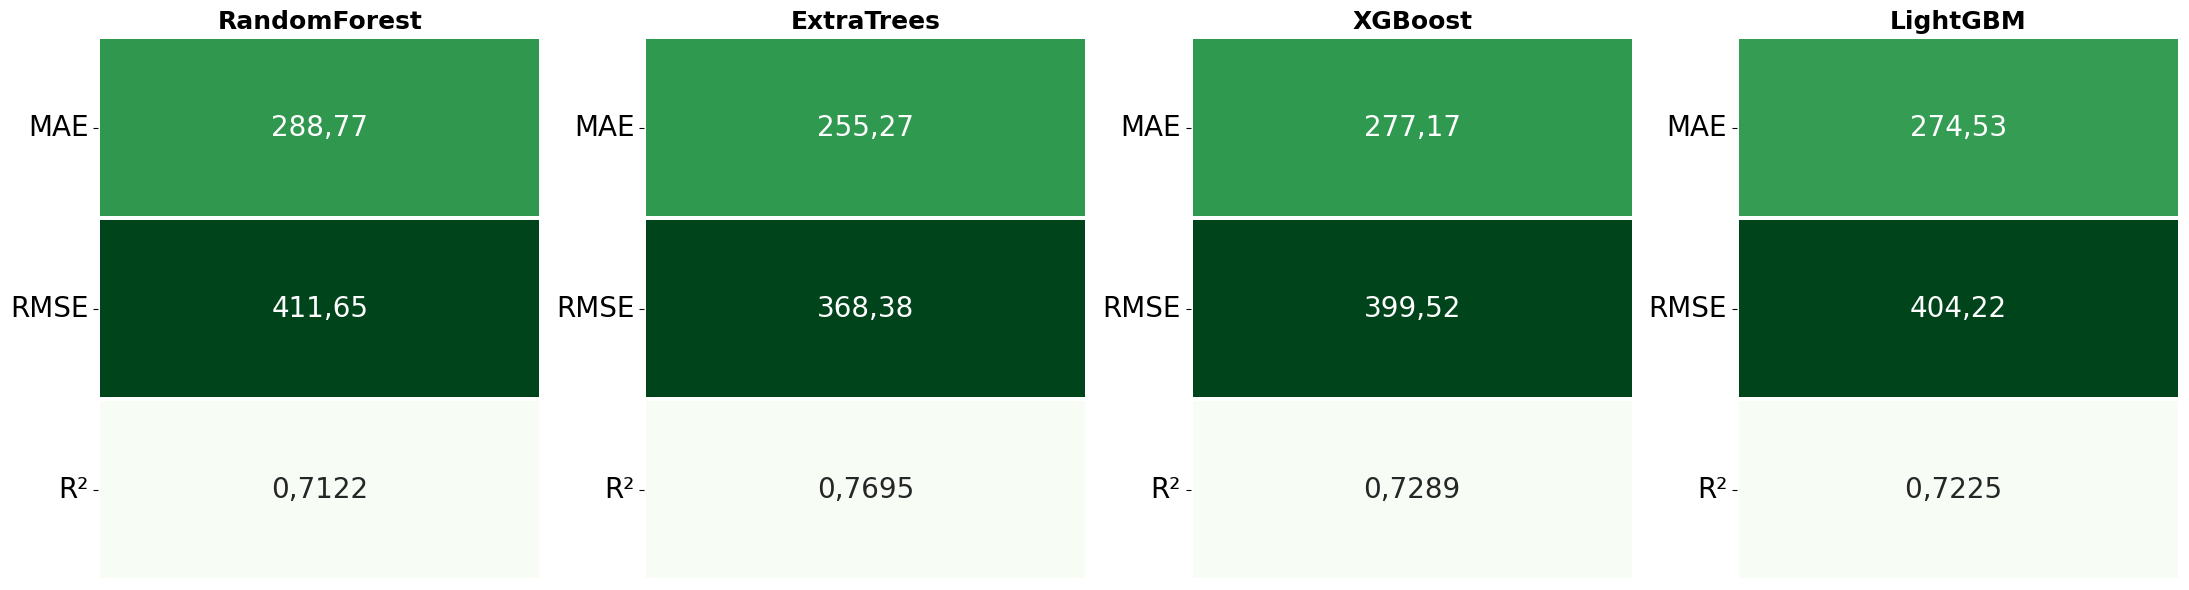

In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import io

# 1. Dados de Performance (Métricas)
raw_perf_data = """Modelo,Métrica,Valor
RandomForest,MAE,"288,77"
RandomForest,RMSE,"411,65"
RandomForest,R²,"0,7122"
ExtraTrees,MAE,"255,27"
ExtraTrees,RMSE,"368,38"
ExtraTrees,R²,"0,7695"
XGBoost,MAE,"277,17"
XGBoost,RMSE,"399,52"
XGBoost,R²,"0,7289"
LightGBM,MAE,"274,53"
LightGBM,RMSE,"404,22"
LightGBM,R²,"0,7225" """

df_perf = pd.read_csv(io.StringIO(raw_perf_data))

# 2. Preparação do Plot (1 linha, 4 colunas) - Seguindo o padrão anterior
models = df_perf['Modelo'].unique()
fig, axes = plt.subplots(1, 4, figsize=(22, 6))
fig.patch.set_facecolor('white')

for i, model in enumerate(models):
    # Filtra dados do modelo
    model_df = df_perf[df_perf['Modelo'] == model].copy()

    # Converte os valores para numérico para definir a intensidade da cor
    # Substituímos vírgula por ponto para o Python entender como float
    model_df['color_val'] = model_df['Valor'].str.replace(',', '.').astype(float)

    # Pivota os dados
    plot_data = model_df.set_index('Métrica')[['color_val']]
    labels = model_df.set_index('Métrica')[['Valor']]

    # Desenha o heatmap (Escala Greens conforme solicitado)
    sns.heatmap(plot_data,
                annot=labels,
                fmt="",
                cmap="Greens",
                cbar=False,
                linewidths=1.5,
                linecolor='white',
                annot_kws={"size": 20},
                ax=axes[i])

    # Estilização idêntica à anterior
    axes[i].set_title(model, fontsize=18, fontweight='bold')

    # Remove labels e ticks do eixo X
    axes[i].set_xlabel("")
    axes[i].set_xticks([])

    # Ajusta o eixo Y
    axes[i].set_ylabel("")
    axes[i].tick_params(axis='y', rotation=0, labelsize=20)

plt.tight_layout()
plt.show()
